# abalone

## Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Exploratory data analysis

In [2]:
df = pd.read_csv('data/abalone.data.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          4177 non-null   str    
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 297.9 KB


<Axes: xlabel='gender'>

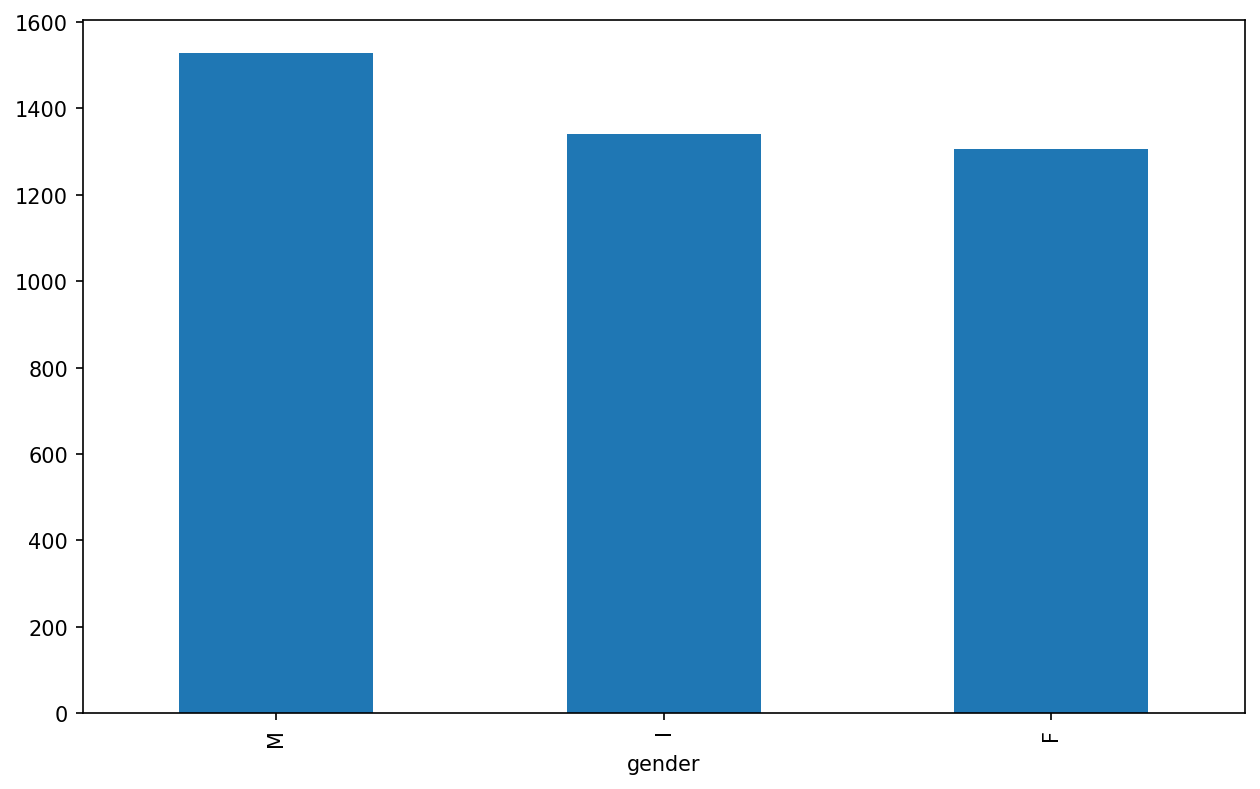

In [4]:
df['gender'].value_counts().plot.bar()

About equal amounts of each gender. Though what is the I
gender?


<Axes: title={'center': 'Rings distribution'}, ylabel='Frequency'>

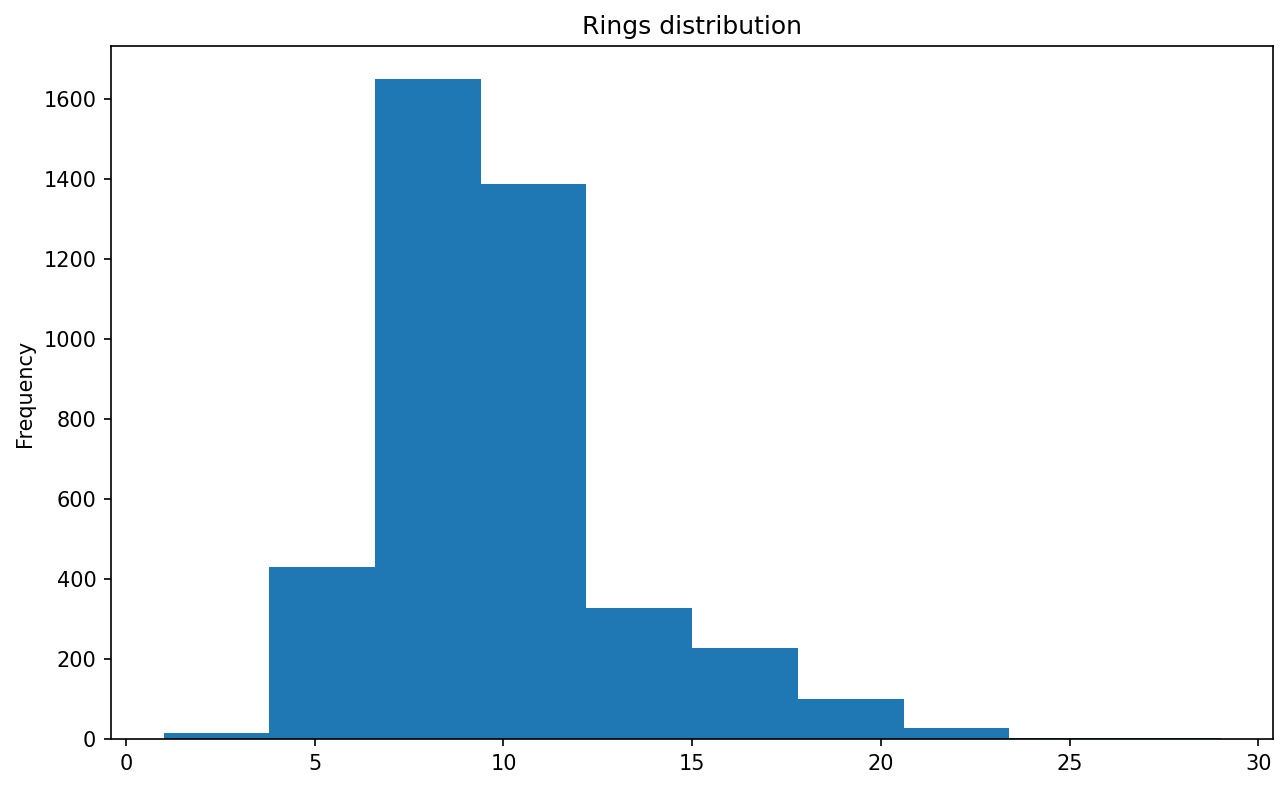

In [5]:
df['Rings'].plot.hist(title='Rings distribution')

 Really unequal distribution of age. Perhaps log is good encoder? Square-root?

array([[<Axes: title={'center': 'Length'}>,
        <Axes: title={'center': 'Diameter'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Whole weight'}>,
        <Axes: title={'center': 'Shucked weight'}>,
        <Axes: title={'center': 'Viscera weight'}>],
       [<Axes: title={'center': 'Shell weight'}>,
        <Axes: title={'center': 'Rings'}>, <Axes: >]], dtype=object)

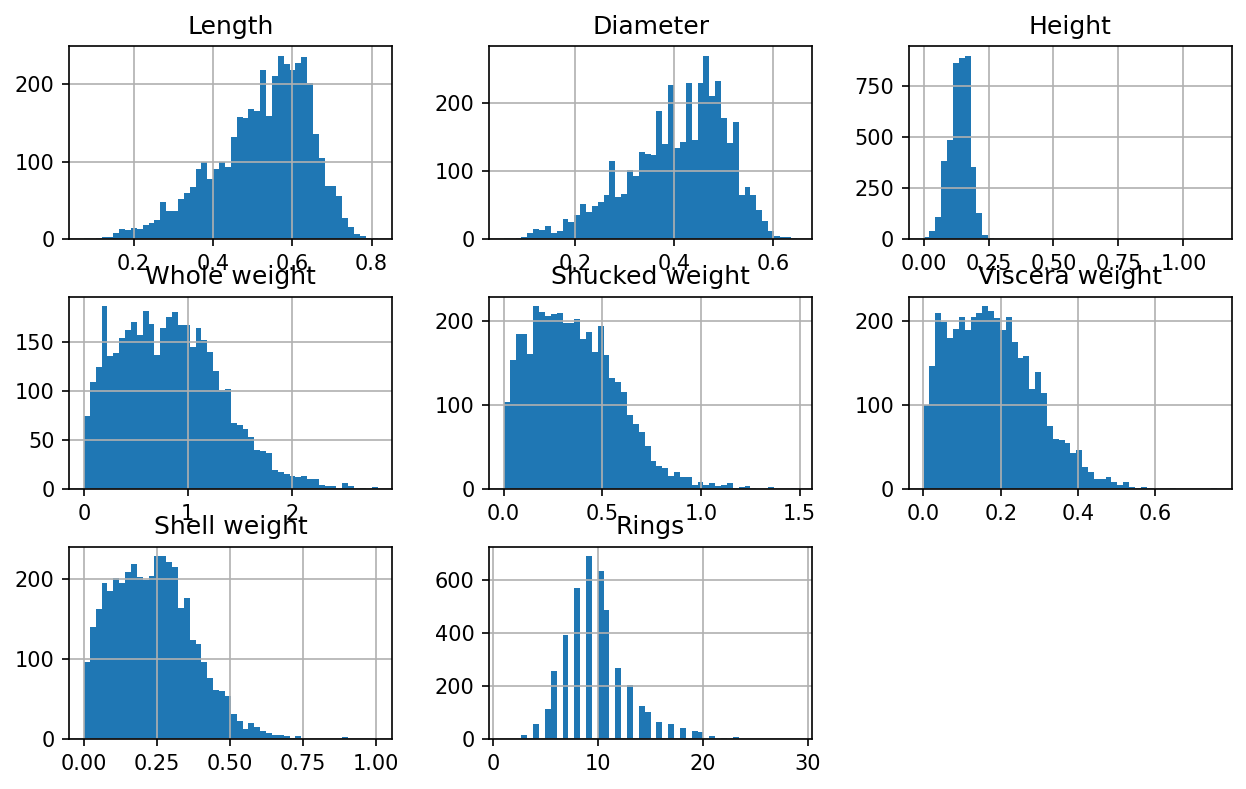

In [6]:
df.hist(bins=50)

### Look for correlations

array([[<Axes: xlabel='Length', ylabel='Length'>,
        <Axes: xlabel='Diameter', ylabel='Length'>,
        <Axes: xlabel='Height', ylabel='Length'>,
        <Axes: xlabel='Whole weight', ylabel='Length'>,
        <Axes: xlabel='Shucked weight', ylabel='Length'>,
        <Axes: xlabel='Viscera weight', ylabel='Length'>,
        <Axes: xlabel='Shell weight', ylabel='Length'>,
        <Axes: xlabel='Rings', ylabel='Length'>],
       [<Axes: xlabel='Length', ylabel='Diameter'>,
        <Axes: xlabel='Diameter', ylabel='Diameter'>,
        <Axes: xlabel='Height', ylabel='Diameter'>,
        <Axes: xlabel='Whole weight', ylabel='Diameter'>,
        <Axes: xlabel='Shucked weight', ylabel='Diameter'>,
        <Axes: xlabel='Viscera weight', ylabel='Diameter'>,
        <Axes: xlabel='Shell weight', ylabel='Diameter'>,
        <Axes: xlabel='Rings', ylabel='Diameter'>],
       [<Axes: xlabel='Length', ylabel='Height'>,
        <Axes: xlabel='Diameter', ylabel='Height'>,
        <Axes: xlabel=

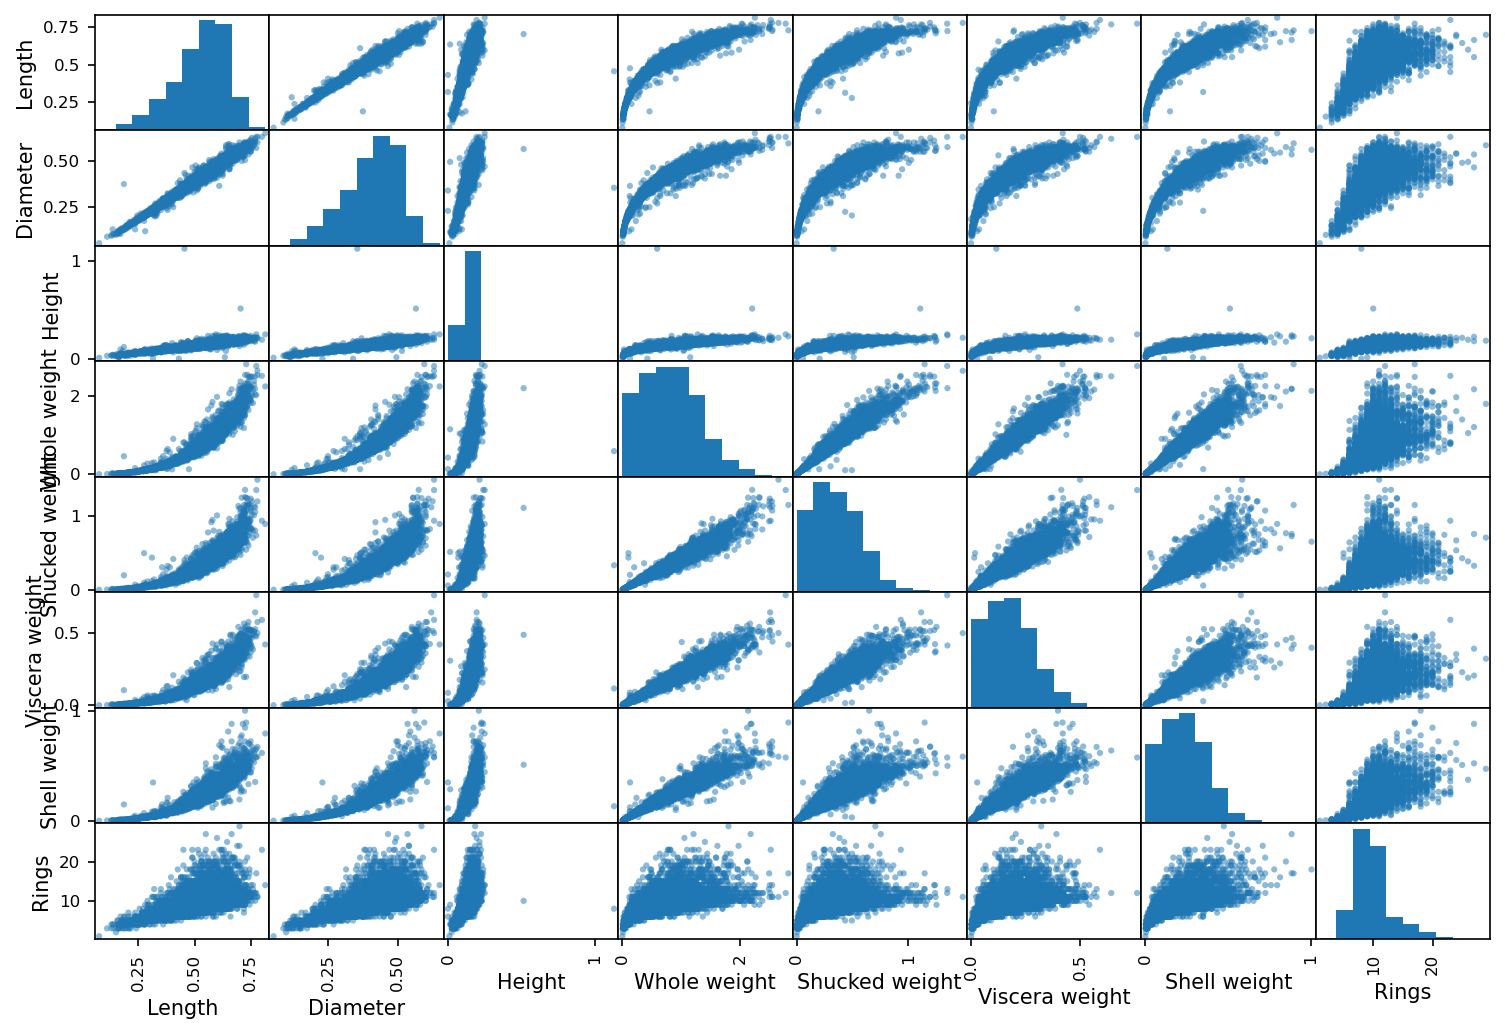

In [7]:
from pandas.plotting import scatter_matrix
numeric = df.columns[df.columns != 'gender']
scatter_matrix(df[numeric], figsize=(12, 8))

## Train-Test Split

In [8]:
train, test = train_test_split(df, test_size=0.2, random_state=47)
X_train = train.drop('Rings', axis=1)
y_train = train['Rings']

## Prepare data for ML models

### Encode str data

In [9]:
from sklearn.preprocessing import OneHotEncoder
oh_encoder = OneHotEncoder()
gender_1hot = oh_encoder.fit_transform(train[['gender']])
gender_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3341 stored elements and shape (3341, 3)>

### Squashing tails

<Axes: >

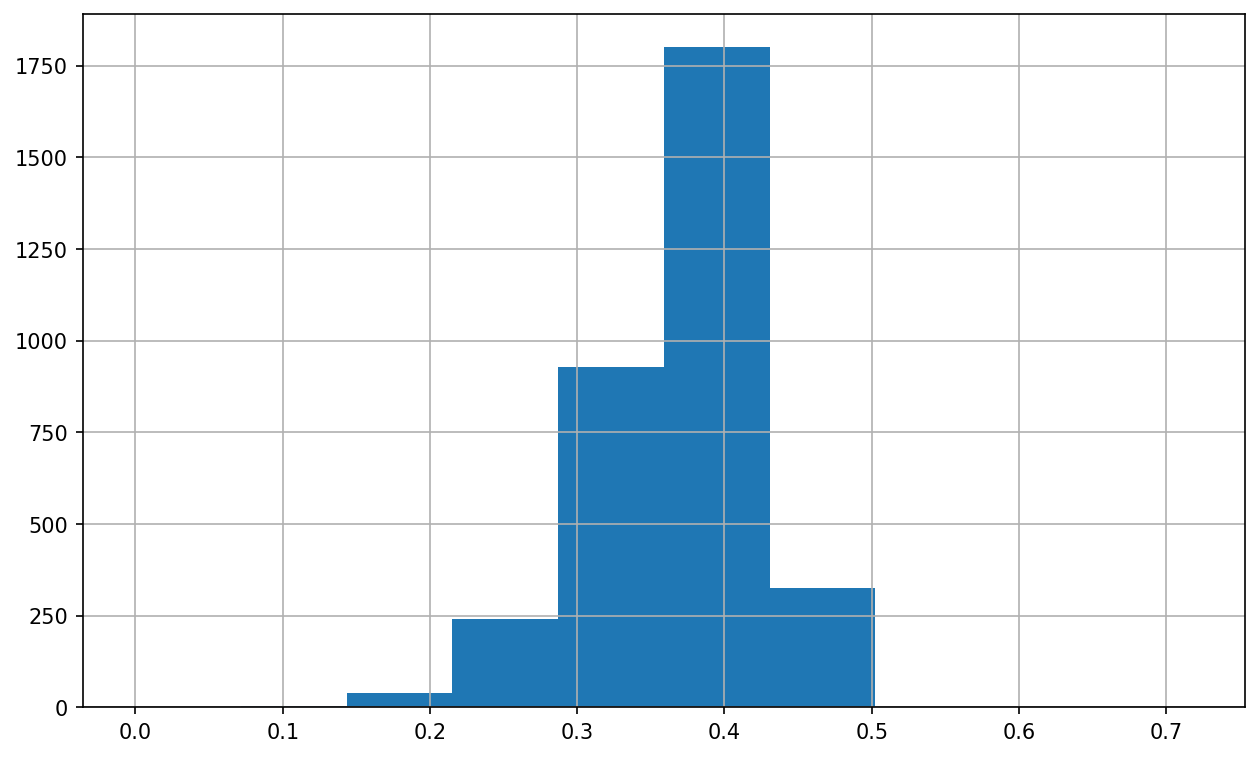

In [10]:
from sklearn.preprocessing import FunctionTransformer
sqrt_transformer = FunctionTransformer(np.sqrt)
sqrt_height = sqrt_transformer.transform(train['Height'])
sqrt_height.hist()

### Transformation Pipeline

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ("sqrt", sqrt_transformer),
    ('standardize', StandardScaler())
])

cat_pipeline = Pipeline([
    ('1hot', OneHotEncoder())
])

num_attribs = list(X_train.columns[X_train.columns != 'gender'])
cat_attribs = ['gender']

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs),
])

train_prepared = preprocessing.fit_transform(X_train)
train_prepared.shape

(3341, 10)

## Model selection, fitness and evaluation

### Linear Regression

In [27]:
from sklearn.metrics import root_mean_squared_error
lr = LinearRegression().fit(train_prepared, y_train)
X_test = test.drop('Rings', axis=1)
y_test = test['Rings']
test_prepared = preprocessing.fit_transform(X_test)
age_predictions = lr.predict(test_prepared)
rmse = root_mean_squared_error(y_test, age_predictions)
rmse

2.020929021762861

Our Linear model has a global risk of 2.02092

In [31]:
train_predictions = lr.predict(train_prepared)
emp_rmse = root_mean_squared_error(y_train, train_predictions)
emp_rmse

2.1715210685000184

### Tree Regressor

In [30]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=47)
tree.fit(train_prepared, y_train)
tree_predictions = tree.predict(test_prepared)
rmse_tree = root_mean_squared_error(y_test, tree_predictions)
rmse_tree

3.0555072249814557